In [89]:
import csv
import numpy as np
from src.roi_classifier.display import COLORS, markers, plot_spectra
import matplotlib.pyplot as plt

In [2]:
filepath = "Mastcam-Z_multispectral_database_sols0-1269.csv"

BAND_LABELS = {
    'iof': [
        "L6",
        "L0B",
        "R0B",
        "L5",
        "L0G",
        "R0G",
        "L4",
        "L0R",
        "R0R",
        "L3",
        "L2",
        "L1",
        "R1",
        "R2",
        "R3",
        "R4",
        "R5",
        "R6",
    ],
    'std': [
        "L6_STD",
        "L0B_STD",
        "R0B_STD",
        "L5_STD",
        "L0G_STD",
        "R0G_STD",
        "L4_STD",
        "L0R_STD",
        "R0R_STD",
        "L3_STD",
        "L2_STD",
        "L1_STD",
        "R1_STD",
        "R2_STD",
        "R3_STD",
        "R4_STD",
        "R5_STD",
        "R6_STD",
    ]
}

In [44]:
all_data = []
with open(filepath, "r") as file:
    csv_reader = csv.reader(file)
    header = next(csv_reader)  # Reads the first line

    for row in csv_reader:
        data = dict(zip(header, row))
        all_data.append(data)

    # Use the header to process subsequent rows
    # for row in csv_reader:
    #     # Access data using header indices
    #     data = dict(zip(header, row))
    #     # Do something with the data
    #     print(data)

    #     data['']

In [133]:
# testing internal functionality... TODO: add to above in open
row = all_data[800]

In [134]:
raw_iofs = [float(row[label]) for label in BAND_LABELS["iof"]]
raw_stds = [float(row[label]) for label in BAND_LABELS["std"]]

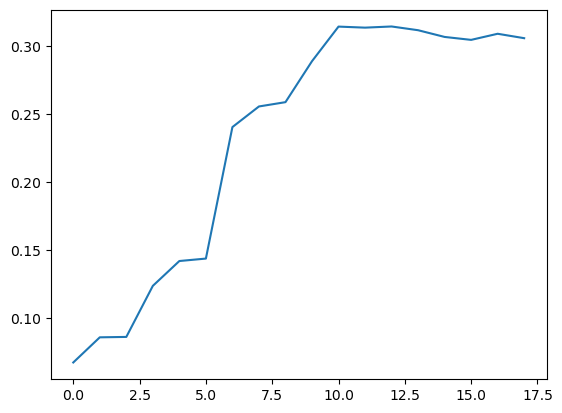

In [135]:
plt.plot(raw_iofs)
plt.show()

In [136]:
WLS = [480, 544, 630, 800, 754, 677, 605, 528, 442, 866, 910, 939, 978, 1022]
RGB_MAPPING = ["B", "G", "R"]

In [137]:
wls_map = {
    1: (1, 2),      # L0B, R0B
    3:(4, 5),       # L0G, R0G
    5: (7, 8),      # L0R, R0R
    8: (11, 12),    # L1, R1
}

# build spectra
iofs = []
i = 0
for _ in range(len(WLS)):
    try:
        # merge overlapping bands
        l_i, r_i = wls_map[i]
        iofs.append((raw_iofs[l_i] + raw_iofs[l_i]) / 2)
        print(BAND_LABELS["iof"][l_i], BAND_LABELS["iof"][r_i])
        i+=2
    except:
        iofs.append(raw_iofs[i])
        i+=1
iofs = np.array(iofs)

stds = []
i = 0
for _ in range(len(WLS)):
    try:
        # merge overlapping bands
        l_i, r_i = wls_map[i]
        stds.append((raw_stds[l_i] + raw_stds[l_i]) / 2)
        i+=2
    except:
        stds.append(raw_stds[i])
        i+=1
stds = np.array(stds)

L0B R0B
L0G R0G
L0R R0R
L1 R1


In [138]:
iofs

array([0.06733567, 0.08585688, 0.14203483, 0.25583497, 0.25583497,
       0.31386927, 0.3146362 , 0.31386927, 0.31472662, 0.3119752 ,
       0.30702433, 0.3048625 , 0.30935702, 0.3061032 ])

In [139]:
WLS

[480, 544, 630, 800, 754, 677, 605, 528, 442, 866, 910, 939, 978, 1022]

In [140]:
iofs

array([0.06733567, 0.08585688, 0.14203483, 0.25583497, 0.25583497,
       0.31386927, 0.3146362 , 0.31386927, 0.31472662, 0.3119752 ,
       0.30702433, 0.3048625 , 0.30935702, 0.3061032 ])

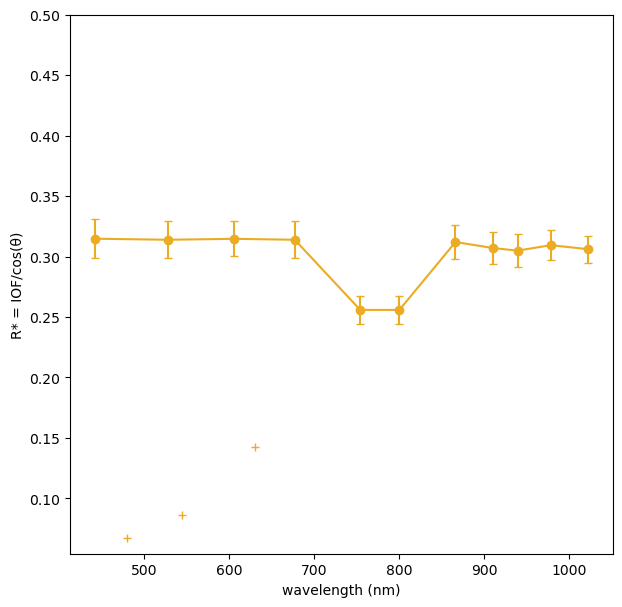

In [141]:
plot_spectra([iofs], [stds])